In [1]:
import re, requests, pandas as pd, GEOparse as gp
import numpy as np
from collections import defaultdict
import pandas as pd
from typing import Dict, List, Tuple
import os, gzip, shutil, subprocess
from pathlib import Path
import warnings
from pandas.errors import DtypeWarning
warnings.filterwarnings("ignore", category=DtypeWarning)
import io
import contextlib

@contextlib.contextmanager
def _quiet_stdout_stderr():
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

In [2]:
# ------------------------ helpers ------------------------
# Cache global: RefSeq/Accession -> Symbol
_ACC2SYM_CACHE: dict[str, str] = {}

def _extract_first_accession(x):
    """Devuelve el primer accession tipo NM_/NR_/XM_/XR_/BC_/BX_...; conserva versión (.1)."""
    if pd.isna(x):
        return np.nan
    t = str(x).strip()
    # separadores típicos en anotaciones
    toks = re.split(r"\s*///\s*|[;,]\s*|\s*\|\s*|\s+", t)
    for tok in toks:
        tok = tok.strip()
        if not tok or tok in {"---", "NA", "na"}:
            continue
        # RefSeq/GenBank accession típicos
        if re.match(r"^(NM|NR|XM|XR|BC|BX|AY|AF|DQ|EU|U|X|Y|Z)_[0-9]+(\.[0-9]+)?$", tok):
            return tok
    return np.nan

def _acc_to_symbol_mygene(acc_list, species="human", chunk_size=1000, retries=3, sleep_s=1.0):
    """
    Devuelve dict {accession: SYMBOL}. Usa MyGene.info querymany con scopes refseq/accession.
    """
    try:
        import mygene
    except ImportError as e:
        raise ImportError("Instala mygene: pip install mygene") from e

    mg = mygene.MyGeneInfo()

    acc_list = [str(a) for a in acc_list if pd.notna(a)]
    # cache
    to_query = [a for a in acc_list if a not in _ACC2SYM_CACHE]

    for i in range(0, len(to_query), chunk_size):
        chunk = to_query[i:i+chunk_size]

        last_err = None
        for att in range(retries):
            try:
                res = mg.querymany(
                    chunk,
                    scopes="refseq,accession",
                    fields="symbol",
                    species=species,
                    as_dataframe=False,
                    returnall=False,
                    verbose=False
                )
                for hit in res:
                    if hit.get("notfound"):
                        continue
                    q = str(hit.get("query", "")).strip()
                    sym = hit.get("symbol", None)
                    if q and sym:
                        _ACC2SYM_CACHE[q] = sym
                last_err = None
                break
            except Exception as e:
                last_err = e
                time.sleep(sleep_s * (att + 1))

        # si falla, no abortamos: seguimos con lo que haya en cache
        if last_err is not None:
            pass

    # construir mapping final
    out = {}
    for a in acc_list:
        sym = _ACC2SYM_CACHE.get(a)
        if sym:
            out[a] = sym
    return out

def _find_accession_col(gpl) -> str | None:
    """Detecta columna tipo GB_ACC / RefSeq / accession en gpl.table."""
    if not hasattr(gpl, "table") or gpl.table is None or gpl.table.empty:
        return None
    cols = list(gpl.table.columns)
    # GPL2700 usa exactamente GB_ACC
    if "GB_ACC" in cols:
        return "GB_ACC"
    # Fallback genérico
    for c in cols:
        nc = str(c).strip().lower()
        if nc in {"gb_acc", "refseq", "refseq_id", "accession", "genbank_accession"}:
            return c
    return None
    
def _df_quantiles_for_logcheck(df: pd.DataFrame):
    """
    Devuelve (q0, q25, q50, q75, q99, q100) ignorando NaNs,
    a partir de todos los valores de la matriz.
    """
    if df.empty:
        return None
    arr = df.to_numpy(dtype=float)
    qs = np.nanquantile(arr, [0.0, 0.25, 0.5, 0.75, 0.99, 1.0])
    return qs  # q0, q25, q50, q75, q99, q100

def _needs_log2(df: pd.DataFrame) -> bool:
    """
    Traducción directa del criterio de R:
    LogC <- (qx[5] > 100) || (qx[6] - qx[1] > 50 && qx[2] > 0)
    (con índices 0-based: q99>100  || (q100-q0>50 && q25>0))
    """
    qs = _df_quantiles_for_logcheck(df)
    if qs is None:
        return False
    q0, q25, q50, q75, q99, q100 = qs
    return (q99 > 100) or ((q100 - q0) > 50 and (q25 > 0))

def _apply_log2_like_R(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    df2 = df.copy()
    df2[df2 <= 0] = 1   # equivalente a: ex[ex <= 0] <- 1
    return np.log2(df2.astype(float))


def _first_item(meta: dict, key: str, default=""):
    v = (meta or {}).get(key, default)
    if isinstance(v, (list, tuple)):
        return v[0] if v else default
    return v

def _norm_key(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[\s/\-]+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s

def _find_gene_col(gpl) -> str | None:
    if not hasattr(gpl, "table") or gpl.table is None or gpl.table.empty:
        return None

    cols = list(gpl.table.columns)

    def norm(c):
        c2 = str(c).strip().lower().replace("_", " ").replace("-", " ")
        return re.sub(r"\s+", " ", c2)

    # 1) Intentar encontrar símbolo (si existiese)
    for c in cols:
        nc = norm(c)
        if re.search(r"\bgene\s*symbol\b", nc):
            return c
    for c in cols:
        nc = norm(c)
        if nc in {"symbol", "gene symbol", "hgnc symbol"} or "gene name" in nc or "gene title" in nc or "gene assignment" in nc:
            return c

    # 2) Fallback: ORF como Entrez Gene ID (caso GPL8542)
    if "ORF" in cols:
        s = pd.to_numeric(gpl.table["ORF"], errors="coerce")
        if s.notna().mean() > 0.90:   # casi todo numérico => muy probablemente Entrez ID
            return "ORF"

    return None

def entrez_to_symbol(entrez_ids, species="human", chunk_size=1000):
    """
    Devuelve dict: { '1': 'A1BG', '10': 'NAT2', ... }
    Usa MyGene.info (API pública).
    """
    url = "https://mygene.info/v3/gene"
    out = {}

    entrez_ids = [str(x) for x in entrez_ids if pd.notna(x)]
    for i in range(0, len(entrez_ids), chunk_size):
        chunk = entrez_ids[i:i+chunk_size]
        r = requests.post(
            url,
            json={"ids": chunk, "fields": "symbol", "species": species},
            timeout=60
        )
        r.raise_for_status()
        data = r.json()

        for item in data:
            # suele venir _id = entrez, y symbol
            eid = str(item.get("_id") or item.get("query") or "")
            sym = item.get("symbol", None)
            if eid and sym:
                out[eid] = sym

    return out


def _extract_first_symbol(x):
    if pd.isna(x): return np.nan
    t = str(x)
    toks = re.split(r"\s*///\s*|[;,]\s*|\s*\|\s*|\s+", t)
    for tok in toks:
        tok = tok.strip()
        if not tok: 
            continue
        if tok in {"---", "NA", "na"}: 
            continue
        if tok.startswith(("NM_","ENSG")):
            continue
        if re.match(r"^[A-Za-z][A-Za-z0-9\-\._]*$", tok):
            return tok
    return np.nan

# ------------------------ metadata (GSE y GSM) ------------------------
def get_gse_metadata(gse) -> pd.DataFrame:
    m = gse.metadata or {}
    row = {
        "gse_accession": gse.name,
        "title":        _first_item(m, "title", ""),
        "summary":      _first_item(m, "summary", ""),
        "overall_design": _first_item(m, "overall_design", ""),
        "type":         _first_item(m, "type", ""),
        "pubmed_id":    _first_item(m, "pubmed_id", ""),
        "submission_date": _first_item(m, "submission_date", ""),
        "status":       _first_item(m, "status", ""),
        "contributor":  ", ".join(m.get("contributor", [])) if "contributor" in m else "",
        "platforms":    ", ".join(sorted(gse.gpls.keys())),
        "n_samples":    len(gse.gsms),
    }
    return pd.DataFrame([row]).set_index("gse_accession")

def expand_characteristics_columns(pheno: pd.DataFrame) -> pd.DataFrame:
    ph = pheno.copy()
    char_cols = [c for c in ph.columns 
                 if re.match(r"characteristics(_ch[12])?(\.\d+)?$", str(c), flags=re.I) 
                 or str(c).lower().startswith("characteristics_ch")]
    extracted = defaultdict(list)
    all_keys = set()
    for idx, row in ph.iterrows():
        kv = {}
        for c in char_cols:
            val = row.get(c, None)
            if pd.isna(val) or str(val).strip() == "":
                continue
            lines = val if isinstance(val, (list, tuple)) else [val]
            flat = []
            for ln in lines:
                if isinstance(ln, str):
                    flat.extend([s for s in re.split(r"\s*;\s*|\s*\|\s*|\n+", ln) if s.strip() != ""])
            for item in flat:
                if ":" in item:
                    k, v = item.split(":", 1)
                    k = _norm_key(k); v = v.strip()
                    if k in kv and kv[k] != v:
                        kv[k] = f"{kv[k]} | {v}"
                    else:
                        kv[k] = v
                else:
                    free_k = "characteristics_free"
                    kv[free_k] = (kv.get(free_k, "") + " | " + str(item).strip()).strip(" |")
        for k, v in kv.items():
            extracted[k].append((idx, v)); all_keys.add(k)
    if not all_keys:
        return ph
    add = pd.DataFrame(index=ph.index, columns=sorted(all_keys), dtype=object)
    for k, pairs in extracted.items():
        for idx, v in pairs:
            add.at[idx, k] = v
    for c in list(add.columns):
        if c in ph.columns:
            add.rename(columns={c: f"{c}_from_char"}, inplace=True)
    return pd.concat([ph, add], axis=1)

def make_sample_metadata(gse) -> pd.DataFrame:
    # base con campos "limpios" directamente de GSM.metadata
    rows = []
    for gsm_id, gsm in gse.gsms.items():
        meta = gsm.metadata or {}
        rows.append({
            "GSM": gsm_id,
            "title": _first_item(meta, "title", ""),
            "organism_ch1": _first_item(meta, "organism_ch1", _first_item(meta, "organism", "")),
            "source_name_ch1": _first_item(meta, "source_name_ch1", _first_item(meta, "source_name", "")),
            "platform_id": _first_item(meta, "platform_id", ""),
            "geo_accession": _first_item(meta, "geo_accession", gsm_id),
            "description": " ".join(meta.get("description", [])) if "description" in meta else "",
            "supplementary_file": "|".join(meta.get("supplementary_file", [])) if "supplementary_file" in meta else "",
        })
    base = pd.DataFrame(rows).set_index("GSM")

    pheno = gse.phenotype_data.copy()
    pheno.index.name = "GSM"

    # 1) join con sufijos para evitar choque de nombres
    merged = base.join(pheno, how="outer", lsuffix="_gsm", rsuffix="_pheno")

    # 2) coalesce de pares duplicados (prioriza *_gsm; si NaN usa *_pheno)
    dupe_cols = ["title","organism_ch1","source_name_ch1","platform_id","geo_accession","description","supplementary_file"]
    for col in dupe_cols:
        cg, cp = f"{col}_gsm", f"{col}_pheno"
        if cg in merged.columns and cp in merged.columns:
            merged[col] = merged[cg].combine_first(merged[cp])
            merged.drop(columns=[cg, cp], inplace=True)
        elif cg in merged.columns:
            merged.rename(columns={cg: col}, inplace=True)
        elif cp in merged.columns:
            merged.rename(columns={cp: col}, inplace=True)

    # 3) expandir characteristics_* a columnas anchas
    merged_expanded = expand_characteristics_columns(merged)

    front = [c for c in ["title","platform_id","organism_ch1","source_name_ch1",
                         "description","supplementary_file"] if c in merged_expanded.columns]
    return merged_expanded[front + [c for c in merged_expanded.columns if c not in front]]

# Cache global opcional para no re-descargar GPLs
# Cache global opcional para no re-descargar GPLs
import time
import numpy as np

# Cache global para no re-consultar Entrez->Symbol
_ENTREZ2SYM_CACHE: dict[str, str] = {}

# Cache global opcional para no re-descargar GPLs
_GPL_CACHE: dict[str, object] = {}

def load_everything_with_metadata(
    gse_id: str,
    destdir: str = "geo",
    platforms: list[str] | None = None,
    annotate_to_gene: bool = True,
    collapse: str = "mean",
    map_entrez_to_symbol: bool = True,     # <-- NUEVO
    drop_unmapped_symbols: bool = True,    # <-- NUEVO: si True, elimina genes sin símbolo
):
    # ---------- 1) Descarga/carga GSE por HTTPS (sin GPL al inicio) ----------
    soft_path = download_gse_family_soft_https(gse_id, destdir=destdir, overwrite=False)
    gse = gp.get_GEO(filepath=soft_path, annotate_gpl=False, silent=True)

    # ---------- helper: descargar GPL .annot.gz por HTTPS ----------
    def _download_gpl_annot_https(gpl_id: str, destdir: str = "geo", overwrite: bool = False) -> str:
        gpl_id = gpl_id.upper()
        stub = re.sub(r"\d{1,3}$", "nnn", gpl_id)
        url = f"https://ftp.ncbi.nlm.nih.gov/geo/platforms/{stub}/{gpl_id}/annot/{gpl_id}.annot.gz"

        dest = Path(destdir)
        dest.mkdir(parents=True, exist_ok=True)
        out = dest / f"{gpl_id}.annot.gz"
        tmp = out.with_suffix(out.suffix + ".part")

        if out.exists() and not overwrite and out.stat().st_size > 0:
            return str(out)

        with requests.get(url, stream=True, timeout=180) as r:
            r.raise_for_status()
            with open(tmp, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
        tmp.replace(out)
        return str(out)

    # ---------- helper: asegurar gpl.table (lazy) ----------
    def _ensure_gpl_with_table(gpl_id: str):
        gpl_id = gpl_id.upper()

        if gpl_id in _GPL_CACHE:
            return _GPL_CACHE[gpl_id]

        gpl0 = gse.gpls.get(gpl_id, None)
        if gpl0 is not None and hasattr(gpl0, "table") and gpl0.table is not None and not gpl0.table.empty:
            _GPL_CACHE[gpl_id] = gpl0
            return gpl0

        # HTTPS annot (si el fichero local está corrupto, reintenta overwrite=True)
        for ow in (False, True):
            try:
                annot_path = _download_gpl_annot_https(gpl_id, destdir=destdir, overwrite=ow)
                gpl1 = gp.get_GEO(filepath=annot_path, silent=True)
                if hasattr(gpl1, "table") and gpl1.table is not None and not gpl1.table.empty:
                    _GPL_CACHE[gpl_id] = gpl1
                    return gpl1
            except Exception:
                pass

        # fallback
        try:
            gpl2 = gp.get_GEO(geo=gpl_id, destdir=destdir, annotate_gpl=True, silent=True)
            if hasattr(gpl2, "table") and gpl2.table is not None and not gpl2.table.empty:
                _GPL_CACHE[gpl_id] = gpl2
                return gpl2
        except Exception:
            pass

        if gpl0 is None:
            raise RuntimeError(f"No se pudo cargar la GPL {gpl_id}.")
        _GPL_CACHE[gpl_id] = gpl0
        return gpl0

    # ---------- helper: adivinar columna de ID de sonda ----------
    def _guess_probe_id_col(gpl_table: pd.DataFrame, expr_index: pd.Index) -> str:
        expr_ids = pd.Index(expr_index.astype(str))

        candidates = [c for c in gpl_table.columns if str(c).strip().upper() in {"ID", "ID_REF"}]
        candidates += [c for c in gpl_table.columns if "probe" in str(c).lower()]
        if not candidates:
            candidates = list(gpl_table.columns[:3])

        best_col = str(gpl_table.columns[0])
        best_hits = -1
        for c in candidates:
            s = gpl_table[c].astype(str)
            hits = expr_ids.isin(pd.Index(s)).sum()
            if hits > best_hits:
                best_hits = hits
                best_col = c
        return best_col

    # ---------- helper: detectar ORF como Entrez (GPL8542) ----------
    def _find_orf_entrez_col(gpl_used) -> str | None:
        if not hasattr(gpl_used, "table") or gpl_used.table is None or gpl_used.table.empty:
            return None
        if "ORF" not in gpl_used.table.columns:
            return None
        s = pd.to_numeric(gpl_used.table["ORF"], errors="coerce")
        # si casi todo es numérico => muy probablemente Entrez ID
        return "ORF" if s.notna().mean() > 0.90 else None

    # ---------- helper: Entrez -> Symbol (MyGene.info) ----------
    def _entrez_to_symbol(entrez_ids, species="human", chunk_size=1000, retries=3, sleep_s=1.0):
        url = "https://mygene.info/v3/gene"
        out = {}

        ids = [str(x) for x in entrez_ids if pd.notna(x)]
        # usa cache
        ids_to_query = [i for i in ids if i not in _ENTREZ2SYM_CACHE]

        for i in range(0, len(ids_to_query), chunk_size):
            chunk = ids_to_query[i:i+chunk_size]

            last_err = None
            for att in range(retries):
                try:
                    r = requests.post(
                        url,
                        json={"ids": chunk, "fields": "symbol", "species": species},
                        timeout=60
                    )
                    r.raise_for_status()
                    data = r.json()
                    for item in data:
                        eid = str(item.get("_id") or item.get("query") or "")
                        sym = item.get("symbol", None)
                        if eid and sym:
                            _ENTREZ2SYM_CACHE[eid] = sym
                    last_err = None
                    break
                except Exception as e:
                    last_err = e
                    time.sleep(sleep_s * (att + 1))

            if last_err is not None:
                # si falla la API, no abortamos: simplemente devolvemos lo que haya
                pass

        # construir mapping final con cache
        for eid in ids:
            sym = _ENTREZ2SYM_CACHE.get(str(eid))
            if sym:
                out[str(eid)] = sym
        return out

    # ---------- 2) Metadatos ----------
    gse_meta_df = get_gse_metadata(gse)
    gsm_meta_df = make_sample_metadata(gse)

    # ---------- 3) Expresión por sonda ----------
    first_gsm = next(iter(gse.gsms.values()))
    value_col = "VALUE" if "VALUE" in first_gsm.table.columns else \
        next(c for c in first_gsm.table.columns if pd.api.types.is_numeric_dtype(first_gsm.table[c]))

    expr_all = gse.pivot_samples(values=value_col)

    def gsm_ids_for_gpl(gpl_id: str):
        ids = []
        for gsm_id, gsm in gse.gsms.items():
            plat = _first_item(gsm.metadata, "platform_id", "")
            if plat == gpl_id:
                ids.append(gsm_id)
        return [x for x in ids if x in expr_all.columns]

    # ---------- 4) Por plataforma ----------
    by_gpl = {}
    gpl_ids = platforms if platforms else list(gse.gpls.keys())

    for gpl_id in gpl_ids:
        if gpl_id not in gse.gpls:
            continue

        gsm_ids = gsm_ids_for_gpl(gpl_id)
        expr_probes = expr_all[gsm_ids].copy() if gsm_ids else pd.DataFrame()

        did_log = False
        if not expr_probes.empty and _needs_log2(expr_probes):
            expr_probes = _apply_log2_like_R(expr_probes)
            did_log = True

        expr_genes = None
        gene_col = None
        probe_id_col = None
        n_mapped = 0
        n_symbol_mapped = 0
        gpl_used = gse.gpls[gpl_id]

        if annotate_to_gene and not expr_probes.empty:
            gpl_used = _ensure_gpl_with_table(gpl_id)

            # 1) intenta gene symbol “normal”
            gene_col = _find_gene_col(gpl_used)

            # 2) fallback: ORF (Entrez)
            if gene_col is None:
                gene_col = _find_orf_entrez_col(gpl_used)

            # 3) fallback: accession (GPL2700 -> GB_ACC)
            accession_col = None
            if gene_col is None:
                accession_col = _find_accession_col(gpl_used)

            # si no hay manera de anotar, saltamos
            if (gene_col is None) and (accession_col is None):
                pass
            else:
                gpl_tbl = gpl_used.table.copy()
                probe_id_col = _guess_probe_id_col(gpl_tbl, expr_probes.index)

                X = expr_probes.copy()
                X.index = X.index.astype(str)

                # =========================================
                # RAMA A) accession (GPL2700: GB_ACC)
                # =========================================
                if accession_col is not None:
                    map_df = gpl_tbl[[probe_id_col, accession_col]].dropna()
                    map_df[probe_id_col] = map_df[probe_id_col].astype(str)
                    map_df = map_df.drop_duplicates(subset=[probe_id_col], keep="first")

                    ann = X.join(map_df.set_index(probe_id_col), how="left")
                    n_mapped = int(ann[accession_col].notna().sum())

                    acc = ann[accession_col].map(_extract_first_accession)
                    acc_unique = pd.Index(acc.dropna().unique()).tolist()

                    m_acc2sym = _acc_to_symbol_mygene(acc_unique, species="human")
                    sym = acc.map(lambda a: m_acc2sym.get(a, np.nan))

                    n_symbol_mapped = int(sym.notna().sum())

                    key = sym if drop_unmapped_symbols else sym.fillna(acc)

                # =========================================
                # RAMA B) gene_col normal o ORF
                # =========================================
                else:
                    # map probe -> gene_col
                    map_df = gpl_tbl[[probe_id_col, gene_col]].dropna()
                    map_df[probe_id_col] = map_df[probe_id_col].astype(str)
                    map_df = map_df.drop_duplicates(subset=[probe_id_col], keep="first")

                    ann = X.join(map_df.set_index(probe_id_col), how="left")
                    n_mapped = int(ann[gene_col].notna().sum())

                    # ORF (Entrez) -> Symbol opcional
                    if gene_col == "ORF" and map_entrez_to_symbol:
                        entrez = pd.to_numeric(ann["ORF"], errors="coerce").astype("Int64")
                        entrez_str = entrez.astype(str)

                        m = _entrez_to_symbol(entrez_str.unique().tolist(), species="human")
                        sym = entrez_str.map(lambda eid: m.get(str(eid), np.nan))

                        n_symbol_mapped = int(sym.notna().sum())
                        key = sym if drop_unmapped_symbols else sym.fillna(entrez_str)
                    else:
                        key = ann[gene_col].map(_extract_first_symbol)
                        n_symbol_mapped = int(key.notna().sum())

                # =========================================
                # COLAPSO UNA SOLA VEZ (mean/median)
                # =========================================
                tmp = ann[gsm_ids].copy()
                tmp["__GENE__"] = key
                tmp = tmp.dropna(subset=["__GENE__"])

                if collapse == "mean":
                    expr_genes = tmp.groupby("__GENE__", dropna=True).mean(numeric_only=True).sort_index()
                elif collapse == "median":
                    expr_genes = tmp.groupby("__GENE__", dropna=True).median(numeric_only=True).sort_index()
                else:
                    raise ValueError("collapse debe ser 'mean' o 'median'")


        by_gpl[gpl_id] = {
            "gpl": gpl_used,
            "gsm_ids": gsm_ids,
            "expr_probes": expr_probes,
            "expr_genes": expr_genes,      # <- ahora ya sale en símbolos (si ORF+API ok)
            "log2_applied": did_log,
            "gene_col": gene_col,
            "probe_id_col": probe_id_col,
            "n_probes": int(expr_probes.shape[0]) if not expr_probes.empty else 0,
            "n_mapped": n_mapped,
            "n_symbol_mapped": n_symbol_mapped,
        }

    return gse, gse_meta_df, gsm_meta_df, by_gpl



def download_gse_family_soft_https(gse_id: str, destdir="geo", overwrite=False) -> str:
    gse_id = gse_id.upper()
    stub = re.sub(r"\d{1,3}$", "nnn", gse_id)  # GSE16011 -> GSE16nnn
    url = f"https://ftp.ncbi.nlm.nih.gov/geo/series/{stub}/{gse_id}/soft/{gse_id}_family.soft.gz"

    dest = Path(destdir)
    dest.mkdir(parents=True, exist_ok=True)
    out = dest / f"{gse_id}_family.soft.gz"
    tmp = out.with_suffix(out.suffix + ".part")

    if out.exists() and not overwrite and out.stat().st_size > 0:
            return str(out)

    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    tmp.replace(out)
    return str(out)


def batch_load_with_metadata(
    jobs: Dict[str, List[str]],
    destdir: str = "geo",
    annotate_to_gene: bool = True,
    collapse: str = "mean",
):
    results: Dict[str, dict] = {}
    series_meta_rows = []
    sample_meta_rows = []

    for gse_id, gpls in jobs.items():
        try:
            gse, gse_meta, gsm_meta, by_gpl = load_everything_with_metadata(
                gse_id,
                destdir=destdir,
                platforms=gpls,
                annotate_to_gene=annotate_to_gene,
                collapse=collapse,
            )
            # guarda resultados por GSE
            results[gse_id] = {
                "gse": gse,
                "gse_meta": gse_meta,
                "gsm_meta": gsm_meta,
                "by_gpl": by_gpl,
            }
            # acumula metadatos “maestros”
            series_meta_rows.append(gse_meta)
            gm = gsm_meta.copy()
            gm.insert(0, "gse_accession", gse_id)
            sample_meta_rows.append(gm)

            print(f"[OK] 🎉 {gse_id}: {list(by_gpl.keys())}")

        except Exception as e:
            print(f"[ERROR] {gse_id}: {e}")

    series_meta = pd.concat(series_meta_rows, axis=0) if series_meta_rows else pd.DataFrame()
    sample_meta = pd.concat(sample_meta_rows, axis=0) if sample_meta_rows else pd.DataFrame()
    return {"results": results, "series_meta": series_meta, "sample_meta": sample_meta}




# Descargar GSE's Completos

In [3]:
data = pd.read_csv('listado_estudios_multitumor_con_controles_v2.csv')
data.loc[data['tumor']=='breast']

,source,tumor,study_id,platdorm,arquitectura
0,GEO,breast,GSE1456,GPL96,Microarray
1,GEO,breast,GSE15852,GPL96,Microarray
2,GEO,breast,GSE162228,GPL570,Microarray
3,GEO,breast,GSE164458,GPL21290,RNA-seq
4,GEO,breast,GSE16446,GPL570,Microarray
5,GEO,breast,GSE19615,GPL570,Microarray
6,GEO,breast,GSE20685,GPL570,Microarray
7,GEO,breast,GSE20711,GPL570,Microarray
8,GEO,breast,GSE21653,GPL570,Microarray
9,GEO,breast,GSE25066,GPL96,Microarray


In [4]:
jobs = {
    "GSE1456": ["GPL96"],#
    "GSE15852": ["GPL96"],#
    "GSE162228" : ["GPL570"],#
    #"GSE164458": ["GPL21290"],#RNA
    #"GSE16446": ["GPL570"],#no subtipo
    "GSE19615": ["GPL570"],#
    #"GSE20685": ["GPL570"],#no subtipo
    "GSE20711": ["GPL570"],#
    "GSE21653": ["GPL570"],#
    "GSE25066": ["GPL96"],#
    "GSE32646": ["GPL570"],#
    "GSE58812": ["GPL570"],#
    "GSE65194": ["GPL570"],#
    #"GSE70947": ["GPL13607"],#pocos genes comunes
    #"GSE7390": ["GPL96"],#no subtipo
    #"GSE96058": ["GPL11154"],#RNA
    
}
batch = batch_load_with_metadata(jobs)

# Crear variables dinamicas
for gse_id, info in batch["results"].items():
    for gpl_id, d in info["by_gpl"].items():
        globals()[f"expr_probes_{gse_id}"] = d["expr_probes"]
        globals()[f"expr_genes_{gse_id}"]  = d["expr_genes"]
        print(f'crado expr_genes_{gse_id} y expr_probes_{gse_id}')
# Variables dinámicas por GSE para METADATA
for gse_id, info in batch["results"].items():
    #globals()[f"gse_meta_{gse_id}"] = info["gse_meta"]  # 1 fila (serie)
    globals()[f"{gse_id}_meta"] = info["gsm_meta"]  # por muestra (GSM)
    print(f"creado gse_meta_{gse_id} y {gse_id}_meta")

[OK] 🎉 GSE1456: ['GPL96']
[OK] 🎉 GSE15852: ['GPL96']
[OK] 🎉 GSE162228: ['GPL570']
[OK] 🎉 GSE19615: ['GPL570']
[OK] 🎉 GSE20711: ['GPL570']
[OK] 🎉 GSE21653: ['GPL570']
[OK] 🎉 GSE25066: ['GPL96']
[OK] 🎉 GSE32646: ['GPL570']
[OK] 🎉 GSE58812: ['GPL570']
[OK] 🎉 GSE65194: ['GPL570']
crado expr_genes_GSE1456 y expr_probes_GSE1456
crado expr_genes_GSE15852 y expr_probes_GSE15852
crado expr_genes_GSE162228 y expr_probes_GSE162228
crado expr_genes_GSE19615 y expr_probes_GSE19615
crado expr_genes_GSE20711 y expr_probes_GSE20711
crado expr_genes_GSE21653 y expr_probes_GSE21653
crado expr_genes_GSE25066 y expr_probes_GSE25066
crado expr_genes_GSE32646 y expr_probes_GSE32646
crado expr_genes_GSE58812 y expr_probes_GSE58812
crado expr_genes_GSE65194 y expr_probes_GSE65194
creado gse_meta_GSE1456 y GSE1456_meta
creado gse_meta_GSE15852 y GSE15852_meta
creado gse_meta_GSE162228 y GSE162228_meta
creado gse_meta_GSE19615 y GSE19615_meta
creado gse_meta_GSE20711 y GSE20711_meta
creado gse_meta_GSE21653 y G

# Seleccionar GSE's 

In [5]:
pd.set_option('display.max_columns', None)

## GSE1456 🎉

In [6]:
subtype_map = {
    'Luminal A': 'LumA',
    'Luminal B': 'LumB',
    'ERBB2': 'HER2',
    'Basal': 'TNBC'
}

GSE1456_meta = GSE1456_meta[GSE1456_meta['characteristics_ch1.6.SUBTYPE'].isin(subtype_map.keys())].copy()
GSE1456_meta['SUBTYPE'] = GSE1456_meta['characteristics_ch1.6.SUBTYPE'].map(subtype_map)
GSE1456_meta = GSE1456_meta[GSE1456_meta['platform_id'] == 'GPL96'].copy()
print(GSE1456_meta['SUBTYPE'].value_counts())
print(f"\nMuestras totales: {len(GSE1456_meta)}")



SUBTYPE
LumA    39
TNBC    25
LumB    23
HER2    15
Name: count, dtype: int64

Muestras totales: 102


In [7]:
expr_genes_GSE1456 = expr_genes_GSE1456[GSE1456_meta.index]
GSE1456_meta.loc[:, 'label'] = GSE1456_meta['SUBTYPE']
GSE1456_meta['batch'] = 'GSE1456'
GSE1456_meta['sample'] = GSE1456_meta['geo_accession'].copy()

In [8]:
print(expr_genes_GSE1456.shape[1], GSE1456_meta.shape[0])

102 102


##  GSE15852 🎉

In [9]:
GSE15852_meta = GSE15852_meta[GSE15852_meta['source_name_ch1'] == 'normal breast tissue'].copy()
expr_genes_GSE15852 = expr_genes_GSE15852[GSE15852_meta.index]

In [10]:
GSE15852_meta.loc[:, 'label'] = 'Normal'
GSE15852_meta['batch'] = 'GSE15852'
GSE15852_meta['sample'] = GSE15852_meta['geo_accession'].copy()

In [11]:
print(expr_genes_GSE15852.shape[1], GSE15852_meta.shape[0])

43 43


## GSE162228 🎉

In [12]:
subtype_map = {
    'Lum-A': 'LumA',
    'Lum-B': 'LumB',
    'HER2': 'HER2',
    'Basal': 'TNBC'
}

GSE162228_meta['characteristics_ch1.10.array_ssp2'] = GSE162228_meta['characteristics_ch1.10.array_ssp2'].map(subtype_map)
expr_genes_GSE162228 = expr_genes_GSE162228[GSE162228_meta.index]

In [13]:
GSE162228_meta.loc[:, 'label'] = GSE162228_meta['characteristics_ch1.10.array_ssp2']
GSE162228_meta['batch'] = 'GSE162228'
GSE162228_meta['sample'] = GSE162228_meta['geo_accession'].copy()

In [14]:
print(expr_genes_GSE162228.shape[1], GSE162228_meta.shape[0])

133 133


##  GSE19615 🎉

In [15]:
GSE19615_meta = GSE19615_meta[((GSE19615_meta['characteristics_ch1.6.er']=='neg') & (GSE19615_meta['characteristics_ch1.7.pr']=='neg') & (GSE19615_meta['characteristics_ch1.8.her.2']=='neg')) | 
                              ((GSE19615_meta['characteristics_ch1.6.er']=='neg') & (GSE19615_meta['characteristics_ch1.7.pr']=='neg') & (GSE19615_meta['characteristics_ch1.8.her.2']=='pos (3+)'))].copy()

GSE19615_meta['label'] = np.where((GSE19615_meta['characteristics_ch1.6.er']=='neg') & (GSE19615_meta['characteristics_ch1.7.pr']=='neg') & (GSE19615_meta['characteristics_ch1.8.her.2']=='neg'),'TNBC','HER2')

expr_genes_GSE19615 = expr_genes_GSE19615[GSE19615_meta.index]


In [16]:
GSE19615_meta['batch'] = 'GSE16446'
GSE19615_meta['sample'] = GSE19615_meta['geo_accession'].copy()

In [17]:
print(expr_genes_GSE19615.shape[1], GSE19615_meta.shape[0])

42 42


##  GSE20711 🎉

In [18]:
subtype_map = {
    'LumA': 'LumA',
    'LumB': 'LumB',
    'HER2': 'HER2',
    'Basal': 'TNBC',
    'Normal' : 'Normal'
}

GSE20711_meta['characteristics_ch1.2.subtypeihc'] = GSE20711_meta['characteristics_ch1.2.subtypeihc'].map(subtype_map)
expr_genes_GSE20711 = expr_genes_GSE20711[GSE20711_meta.index]

In [19]:
GSE20711_meta.loc[:, 'label'] = GSE20711_meta['characteristics_ch1.2.subtypeihc']
GSE20711_meta['batch'] = 'GSE20711'
GSE20711_meta['sample'] = GSE20711_meta['geo_accession'].copy()

In [20]:
print(expr_genes_GSE20711.shape[1], GSE20711_meta.shape[0])

90 90


##  GSE21653 🎉

In [21]:
subtype_map = {
    'LuminalA': 'LumA',
    'LuminalB': 'LumB',
    'ERBB2': 'HER2',
    'Basal': 'TNBC',
    'Normal' : 'Normal'
}
mol_cols = [col for col in GSE21653_meta.columns if 'molecular subtype' in col.lower()]
GSE21653_meta['molecular_subtype'] = GSE21653_meta[mol_cols].bfill(axis=1).iloc[:, 0]

GSE21653_meta['molecular_subtype'] = GSE21653_meta['molecular_subtype'].map(subtype_map)
expr_genes_GSE21653 = expr_genes_GSE21653[GSE21653_meta.index]

In [22]:
GSE21653_meta.loc[:, 'label'] = GSE21653_meta['molecular_subtype']
GSE21653_meta['batch'] = 'GSE21653'
GSE21653_meta['sample'] = GSE21653_meta['geo_accession'].copy()

In [23]:
print(expr_genes_GSE21653.shape[1], GSE21653_meta.shape[0])

266 266


##  GSE25066 🎉

In [24]:
subtype_map = {
    'LumA': 'LumA',
    'LumB': 'LumB',
    'Her2': 'HER2',
    'Basal': 'TNBC',
    'Normal' : 'Normal'
}

GSE25066_meta['characteristics_ch1.20.pam50_class'] = GSE25066_meta['characteristics_ch1.20.pam50_class'].map(subtype_map)
expr_genes_GSE25066 = expr_genes_GSE25066[GSE25066_meta.index]

In [25]:
GSE25066_meta.loc[:, 'label'] = GSE25066_meta['characteristics_ch1.20.pam50_class']
GSE25066_meta['batch'] = 'GSE25066'
GSE25066_meta['sample'] = GSE25066_meta['geo_accession'].copy()

In [26]:
print(expr_genes_GSE25066.shape[1], GSE25066_meta.shape[0])

508 508


##  GSE32646 🎉

In [27]:
GSE32646_meta = GSE32646_meta[((GSE32646_meta['characteristics_ch1.6.er status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.7.pr status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.8.her2 status fish']=='negative')) | 
                              ((GSE32646_meta['characteristics_ch1.6.er status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.7.pr status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.8.her2 status fish']=='positive'))].copy()

GSE32646_meta['label'] = np.where((GSE32646_meta['characteristics_ch1.6.er status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.7.pr status ihc']=='negative') & (GSE32646_meta['characteristics_ch1.8.her2 status fish']=='negative'),'TNBC','HER2')

expr_genes_GSE32646 = expr_genes_GSE32646[GSE32646_meta.index]


In [28]:
GSE32646_meta['batch'] = 'GSE32646'
GSE32646_meta['sample'] = GSE32646_meta['geo_accession'].copy()

In [29]:
print(expr_genes_GSE32646.shape[1], GSE32646_meta.shape[0])

44 44


##  GSE58812 🎉

In [30]:
subtype_map = {
    'triple negative breast cancer': 'TNBC',

}

GSE58812_meta['characteristics_ch1.0.diagnosis'] = GSE58812_meta['characteristics_ch1.0.diagnosis'].map(subtype_map)
expr_genes_GSE58812 = expr_genes_GSE58812[GSE58812_meta.index]

In [31]:
GSE58812_meta.loc[:, 'label'] = GSE58812_meta['characteristics_ch1.0.diagnosis']
GSE58812_meta['batch'] = 'GSE58812'
GSE58812_meta['sample'] = GSE58812_meta['geo_accession'].copy()

In [32]:
print(expr_genes_GSE58812.shape[1], GSE58812_meta.shape[0])

107 107


##  GSE65194 🎉

In [33]:
subtype_map = {
    'Luminal A': 'LumA',
    'Luminal B': 'LumB',
    'Her2': 'HER2',
    'TNBC': 'TNBC',
    'Healthy' : 'Normal'
}

GSE65194_meta = GSE65194_meta[GSE65194_meta['characteristics_ch1.0.sample_group'].isin(subtype_map.keys())].copy()
GSE65194_meta['SUBTYPE'] = GSE65194_meta['characteristics_ch1.0.sample_group'].map(subtype_map)

In [34]:
expr_genes_GSE65194 = expr_genes_GSE65194[GSE65194_meta.index]
GSE65194_meta.loc[:, 'label'] = GSE65194_meta['SUBTYPE']
GSE65194_meta['batch'] = 'GSE6519'
GSE65194_meta['sample'] = GSE65194_meta['geo_accession'].copy()

In [35]:
print(expr_genes_GSE65194.shape[1], GSE65194_meta.shape[0])

164 164


##  GSE70947 🎉

# No Valen

##  GSE20685 🎉

##  GSE16446 🎉

##  GSE7390 🎉

#  🌍 Juntar todos los Microarrays GSE y todo metadata gsm y Label 

In [36]:
# ================================================
#  Unir expr_genes_* + (gse_meta_* | *_meta) → mega-tablas
#  - expr_genes_microarrays: genes x muestras
#  - microarrays_meta: sample, batch(=ID), label (si hay), ...
# ================================================
import re
import os
import pandas as pd
import numpy as np

# ---- Config ----
PREFER_INTERSECTION = True   # si False → UNIÓN de genes (rellena con NA)
MIN_COMMON_GENES_WARN = 1000

# ---- Helpers ----
def _norm_sample_id(x: str) -> str:
    """basename, quita .CEL/.CEL.gz y espacios."""
    x = os.path.basename(str(x))
    x = re.sub(r"\.CEL(\.gz)?$", "", x, flags=re.IGNORECASE)
    return x.strip()

def _find_meta_obj_name(study_id: str, globs: dict) -> str | None:
    """
    Busca metadata para un ID de estudio arbitrario:
      - gse_meta_<ID>
      - <ID>_meta
    """
    cands = [f"gse_meta_{study_id}", f"{study_id}_meta"]
    for nm in cands:
        if nm in globs:
            return nm
    return None

def _extract_sample_series(meta_df: pd.DataFrame) -> pd.Series:
    """
    Devuelve una Serie 'sample' a partir del DataFrame de metadatos.
    Usa 'sample' si existe; si no, intenta columnas SDRF típicas.
    """
    cols_lower = {c.lower(): c for c in meta_df.columns}
    if "sample" in cols_lower:
        return meta_df[cols_lower["sample"]].astype(str).map(_norm_sample_id)

    # SDRF / MAGE-TAB comunes
    candidates = [
        "assay name", "sample name", "source name",
        "array data file", "derived array data file","geo_accession",
        "array data matrix file"
    ]
    for cand in candidates:
        if cand in cols_lower:
            return meta_df[cols_lower[cand]].astype(str).map(_norm_sample_id)

    # último recurso: índice llamado 'sample'
    if meta_df.index.name and str(meta_df.index.name).lower() == "sample":
        return pd.Series(meta_df.index.map(_norm_sample_id), index=meta_df.index, name="sample")

    raise ValueError("No se pudo inferir la columna 'sample' en metadata.")

def build_mega_tables_from_globals(globs: dict, expr_prefix: str = "expr_genes_"):
    """
    Recolecta todos los DataFrames cuyo nombre empieza por `expr_prefix`
    (p. ej., expr_genes_* o expr_probes_*), busca su metadata emparejada,
    y devuelve (expr_mega, meta_mega).
    """
    # 1) localizar objetos de expresión por prefijo
    expr_varnames = [nm for nm in globs.keys() if nm.startswith(expr_prefix)]
    if not expr_varnames:
        raise RuntimeError(f"No se encontraron objetos que empiecen por '{expr_prefix}'.")

    # extraer el ID de estudio tras el prefijo (lo que venga: GSE…, E-MTAB…, etc.)
    study_ids = [nm[len(expr_prefix):] for nm in expr_varnames]
    # mantener orden estable
    expr_pairs = sorted(zip(study_ids, expr_varnames), key=lambda x: x[0])

    expr_list = []
    meta_rows = []

    print("Detectados estudios:", ", ".join(study_ids))

    for study_id, varname in expr_pairs:
        X = globs[varname]
        if not isinstance(X, pd.DataFrame):
            raise TypeError(f"{varname} no es un DataFrame.")
        if X.index.name is None:
            X.index.name = "gene"

        # columnas originales (IDs de muestra)
        orig_cols = [str(c) for c in X.columns]

        # --- metadata
        meta_name = _find_meta_obj_name(study_id, globs)
        if meta_name is None:
            # meta mínimo si no hay objeto de metadata emparejado
            meta_df = pd.DataFrame({"sample": orig_cols})
        else:
            mdf = globs[meta_name]
            if not isinstance(mdf, pd.DataFrame):
                mdf = pd.DataFrame(mdf)
            smp = _extract_sample_series(mdf)
            meta_df = mdf.copy()
            meta_df["sample"] = smp.values

        # --- prefijo <ID>: para evitar colisiones entre estudios
        prefixed_cols = [f"{study_id}:{_norm_sample_id(c)}" for c in orig_cols]
        X_pref = X.copy()
        X_pref.columns = prefixed_cols

        meta_df["sample"] = meta_df["sample"].astype(str).map(_norm_sample_id).map(lambda s: f"{study_id}:{s}")
        meta_df["batch"] = study_id  # batch = ID de estudio

        expr_list.append(X_pref)
        meta_rows.append(meta_df)

    # 2) Alinear genes entre estudios
    gene_sets = [set(df.index) for df in expr_list]
    if PREFER_INTERSECTION:
        common_genes = sorted(set.intersection(*gene_sets))
        if len(common_genes) < MIN_COMMON_GENES_WARN:
            print(f"⚠️ Aviso: genes comunes = {len(common_genes)} (revisa anotaciones/platforms).")
        expr_list_aligned = [df.loc[common_genes] for df in expr_list]
    else:
        all_genes = sorted(set.union(*gene_sets))
        expr_list_aligned = [df.reindex(all_genes) for df in expr_list]

    # 3) Concatenar columnas
    expr_mega = pd.concat(expr_list_aligned, axis=1)

    # 4) Combinar metadata y filtrar a muestras presentes
    meta_mega = pd.concat(meta_rows, axis=0, ignore_index=True)
    meta_mega = meta_mega.drop_duplicates(subset=["sample"], keep="last")
    cols_present = set(expr_mega.columns)
    meta_mega = meta_mega[meta_mega["sample"].isin(cols_present)].copy()

    # Ordenar columnas útiles primero
    front = ["sample", "batch"] + (["label"] if "label" in meta_mega.columns else [])
    rest = [c for c in meta_mega.columns if c not in front]
    meta_mega = meta_mega[front + rest]

    print("✓ Combinación realizada.")
    print(f"   Genes:    {expr_mega.shape[0]}")
    print(f"   Muestras: {expr_mega.shape[1]}")
    print(f"   Batches:  {meta_mega['batch'].nunique()}")

    return expr_mega, meta_mega

# --------- Ejecuta para expr_genes_ ---------
expr_genes_microarrays, microarrays_meta = build_mega_tables_from_globals(globals(), expr_prefix="expr_genes_")


# --------- Si quieres repetir para probes ---------
# expr_probes_microarrays, microarrays_meta_probes = build_mega_tables_from_globals(globals(), expr_prefix="expr_probes_")


Detectados estudios: GSE1456, GSE15852, GSE162228, GSE19615, GSE20711, GSE21653, GSE25066, GSE32646, GSE58812, GSE65194
✓ Combinación realizada.
   Genes:    13236
   Muestras: 1499
   Batches:  10


In [37]:
microarrays_meta = microarrays_meta[['sample','batch','label']]
microarrays_meta['batch'].value_counts()

batch
GSE25066     508
GSE21653     266
GSE65194     164
GSE162228    133
GSE58812     107
GSE1456      102
GSE20711      90
GSE32646      44
GSE15852      43
GSE19615      42
Name: count, dtype: int64

In [38]:
# TOTAL de NaN en todo el DataFrame
total_nans = expr_genes_microarrays.isna().sum().sum()

# NaN POR COLUMNA (ordenado de mayor a menor)
nans_por_col = expr_genes_microarrays.isna().sum().sort_values(ascending=False)

# Porcentaje de NaN POR COLUMNA
pct_nans_por_col = (expr_genes_microarrays.isna().mean() * 100).sort_values(ascending=False)

# Número de columnas que tienen al menos un NaN
num_cols_con_nan = expr_genes_microarrays.isna().any().sum()

# Columnas que tienen NaN
cols_con_nan = expr_genes_microarrays.columns[expr_genes_microarrays.isna().any()].tolist()

# NaN POR FILA
nans_por_fila = expr_genes_microarrays.isna().sum(axis=1)

print("Total NaN:", total_nans)
print("Columnas con NaN:", num_cols_con_nan)
print("Top columnas con NaN:\n", nans_por_col.head())

Total NaN: 0
Columnas con NaN: 0
Top columnas con NaN:
 GSE65194:GSM1589151    0
GSE1456:GSM107073      0
GSE1456:GSM107074      0
GSE1456:GSM107076      0
GSE1456:GSM107077      0
dtype: int64


In [39]:
n_before = len(expr_genes_microarrays)
expr_genes_microarrays = expr_genes_microarrays.dropna(axis=0, how="any")
print("Filas eliminadas:", n_before - len(expr_genes_microarrays))

Filas eliminadas: 0


In [40]:
# (Opcional) Guardar
expr_genes_microarrays.to_csv("./Data/expr_genes_microarrays.csv")
microarrays_meta.to_csv("./Data/microarrays_meta.csv", index=False)


In [41]:
microarrays_meta['label'].value_counts()

label
TNBC      549
LumA      384
LumB      242
HER2      195
Normal    129
Name: count, dtype: int64

In [42]:
microarrays_meta.shape

(1499, 3)

In [43]:
expr_genes_microarrays.shape

(13236, 1499)

Var. explicada: PC1=0.508, PC2=0.108
✓ Guardado: pca_expr_genes_by_batch.png


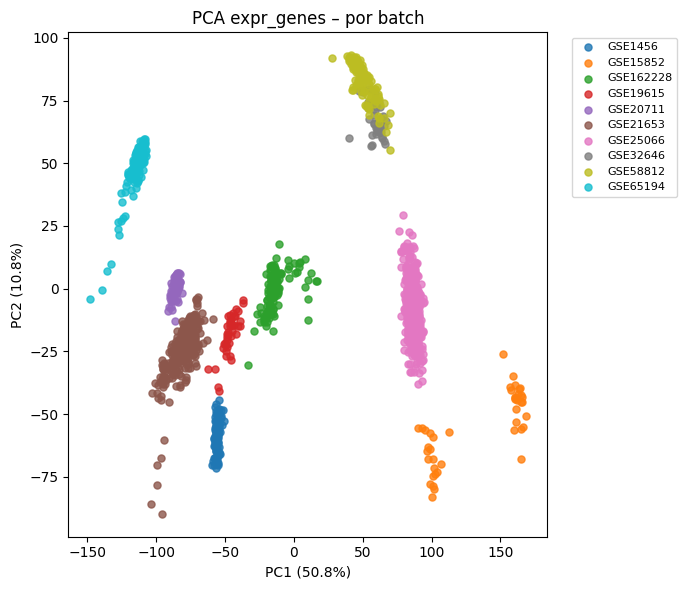

Var. explicada: PC1=0.508, PC2=0.108
✓ Guardado: pca_expr_genes_by_label.png


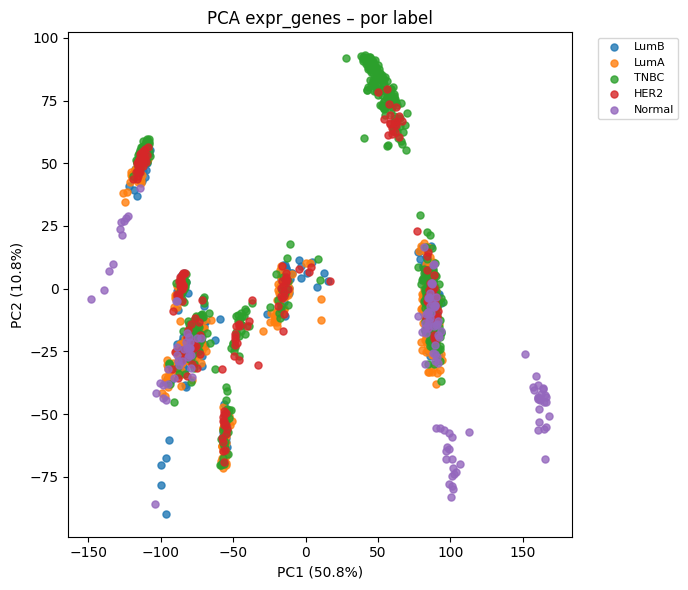

In [44]:
# ================================================
#  PCA / QC – sobre la matriz combinada
# ================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def compute_pca_embeddings(expr_df: pd.DataFrame,
                           n_components: int = 2,
                           center: bool = True,
                           scale: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """
    PCA sobre MUESTRAS:
      - expr_df: genes x muestras
      - center: resta media por gen
      - scale : divide por sd por gen (z-score). Útil si mezclas plataformas.
    Devuelve (embeddings n_muestras x n_components, var_explicada_por_componente).
    """
    X = expr_df.copy()

    # Centrado/escala por GEN (filas)
    if center:
        mu = X.mean(axis=1)
        X = X.sub(mu, axis=0)
    if scale:
        sd = X.std(axis=1).replace(0, np.nan)
        X = X.div(sd, axis=0).fillna(0.0)

    pca = PCA(n_components=n_components, svd_solver="auto", random_state=0)
    emb = pca.fit_transform(X.T)  # muestras x componentes
    varexp = pca.explained_variance_ratio_
    print(f"Var. explicada: {', '.join(f'PC{i+1}={v:.3f}' for i, v in enumerate(varexp[:n_components]))}")
    return emb, varexp

def plot_pca(expr_df: pd.DataFrame,
             meta_df: pd.DataFrame,
             color_col: str = "batch",
             title: str = "PCA (muestras)",
             savepath: str | None = None,
             center: bool = True,
             scale: bool = False):
    """
    Dibuja PC1 vs PC2 coloreado por 'color_col' (p. ej., 'batch' o 'label').
    No fija colores manualmente (usa los de matplotlib por defecto).
    """
    # Reordenar metadata al orden de columnas de la expresión
    m = meta_df.set_index("sample").reindex(expr_df.columns)
    if m[color_col].isna().any():
        # Aviso si faltan anotaciones para alguna muestra
        faltan = m.index[m[color_col].isna()].tolist()
        print(f"⚠️ Faltan valores en '{color_col}' para {len(faltan)} muestras (p.ej.: {faltan[:5]})")

    emb, varexp = compute_pca_embeddings(expr_df, n_components=2, center=center, scale=scale)

    plt.figure(figsize=(7, 6))
    cats = pd.Series(m[color_col].values, index=m.index)
    for cat in pd.unique(cats):
        mask = (cats == cat).values
        plt.scatter(emb[mask, 0], emb[mask, 1], label=str(cat), alpha=0.8, s=26)

    plt.xlabel(f"PC1 ({varexp[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({varexp[1]*100:.1f}%)")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✓ Guardado: {savepath}")
    plt.show()

# ==== Ejemplos de uso inmediato (después de construir expr_genes_microarrays y microarrays_meta) ====

# PCA coloreado por batch (recomendado: centrar; escalar si mezclas plataformas muy distintas)
plot_pca(expr_genes_microarrays, microarrays_meta,
         color_col="batch",
         title="PCA expr_genes – por batch",
         savepath="pca_expr_genes_by_batch.png",
         center=True, scale=True)

# PCA coloreado por label (si existe en metadata)
if "label" in microarrays_meta.columns:
    plot_pca(expr_genes_microarrays, microarrays_meta,
             color_col="label",
             title="PCA expr_genes – por label",
             savepath="pca_expr_genes_by_label.png",
             center=True, scale=True)


In [45]:
expr_genes_microarrays.shape

(13236, 1499)

In [46]:
microarrays_meta.shape

(1499, 3)